In [10]:
import json
import pandas as pd

# Load the JSON file (put the correct path if it's elsewhere)
with open("BSRNN/vocals/history.json", "r") as f:
    rnn_data = json.load(f)

with open("TFSWA/vocals/history.json", "r") as f:
    tf_data = json.load(f) 

# Case 1: history.json is a list of records, e.g. [{...}, {...}, ...]
tf_df = pd.DataFrame(tf_data)
rnn_df = pd.DataFrame(rnn_data)

# If instead your metrics are under a key, e.g. {"history": [{...}, ...]}
# df = pd.DataFrame(data["history"])

display(tf_df.head())
display(rnn_df.head())

,epoch,train,val_loss,val_SDR,n_songs
0,1,0.023877,0.013559,NaN,0
1,2,0.021882,0.012204,NaN,0
2,3,0.021268,0.011427,NaN,0
3,4,0.020759,0.012492,NaN,0
4,5,0.019964,0.013598,0.829321,16


,epoch,train,val,val_uSDR,val_cSDR
0,1,0.622130,0.637297,NaN,NaN
1,2,0.614583,0.580740,1.160875,0.621279
2,3,0.599175,0.737793,NaN,NaN
3,4,0.611980,0.550882,1.306793,0.748742
4,5,0.591305,0.607964,NaN,NaN


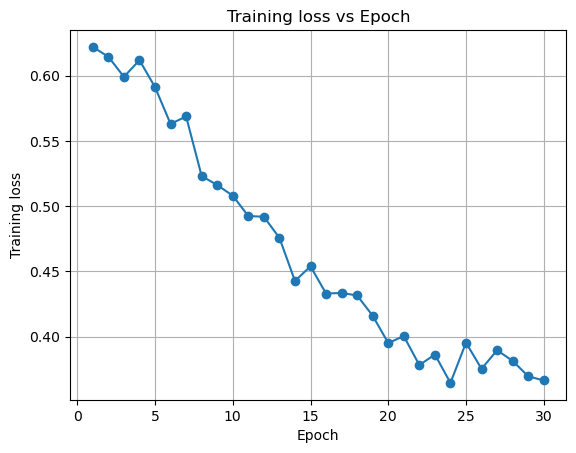

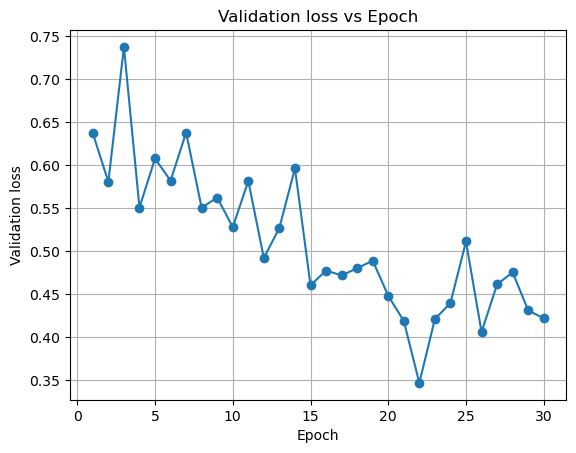

In [8]:
import matplotlib.pyplot as plt

# Training loss vs epoch
plt.figure()
plt.plot(df["epoch"], df["train"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Training loss vs Epoch")
plt.grid(True)
plt.show()

# Val loss vs epoch
plt.figure()
plt.plot(df["epoch"], df["val"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Validation loss vs Epoch")
plt.grid(True)
plt.show()


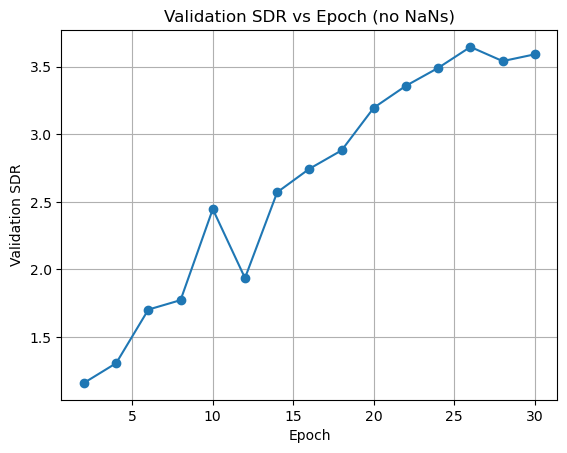

In [9]:
# Keep only rows where val_sdr is NOT NaN
df_clean = df[df["val_uSDR"].notna()].copy()

# Optional: reset index
df_clean.reset_index(drop=True, inplace=True)

# Example: plot val_sdr vs epoch using only valid epochs
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_clean["epoch"], df_clean["val_uSDR"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation SDR")
plt.title("Validation SDR vs Epoch (no NaNs)")
plt.grid(True)
plt.show()

C:\Users\rkb1u25\AppData\Local\Temp\ipykernel_29548\2950712578.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


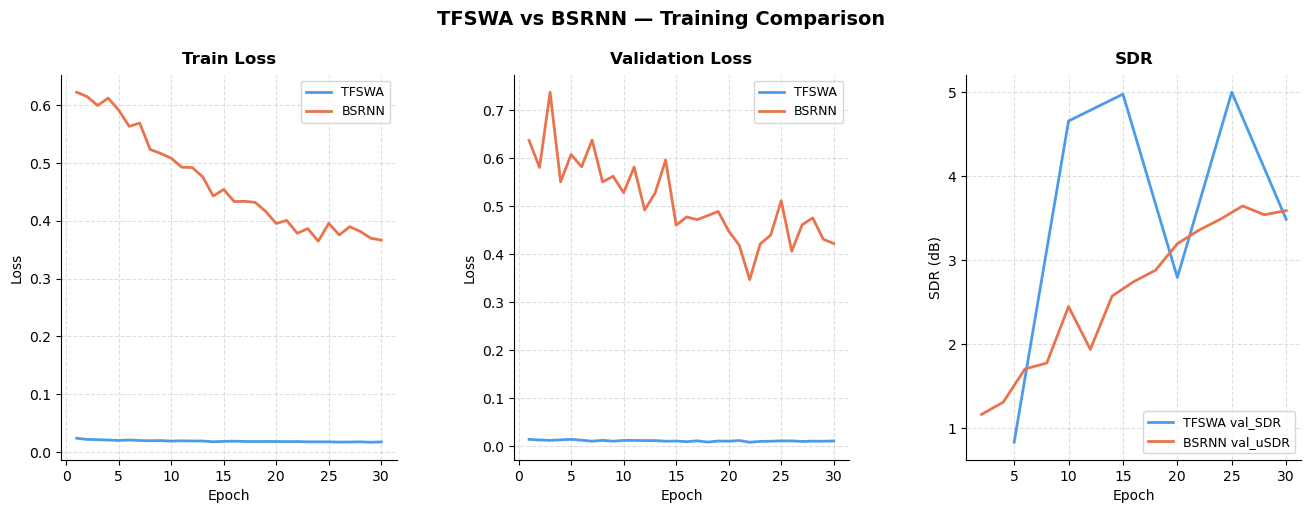

In [11]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Load ──────────────────────────────────────────────────────────────────────
with open("BSRNN/vocals/history.json", "r") as f:
    rnn_data = json.load(f)
with open("TFSWA/vocals/history.json", "r") as f:
    tf_data = json.load(f)

tf_df  = pd.DataFrame(tf_data)
rnn_df = pd.DataFrame(rnn_data)

# ── Consolidate into a common schema ─────────────────────────────────────────
# tf_df  cols: epoch | train      | val_loss | val_SDR  | n_songs
# rnn_df cols: epoch | train      | val      | val_uSDR | val_cSDR

tf_clean = pd.DataFrame({
    "epoch"     : tf_df["epoch"],
    "train_loss": tf_df["train"],
    "val_loss"  : tf_df["val_loss"],
    "val_SDR"   : tf_df["val_SDR"],
}).dropna(subset=["val_loss"])          # rows without validation are excluded

rnn_clean = pd.DataFrame({
    "epoch"     : rnn_df["epoch"],
    "train_loss": rnn_df["train"],
    "val_loss"  : rnn_df["val"],
    "val_SDR"   : rnn_df["val_uSDR"],
}).dropna(subset=["val_loss"])

# ── Plot ──────────────────────────────────────────────────────────────────────
COLORS = {"tf": "#4C9BE8", "rnn": "#E8734C"}
LABELS = {"tf": "TFSWA", "rnn": "BSRNN"}

fig = plt.figure(figsize=(16, 5))
fig.suptitle("TFSWA vs BSRNN — Training Comparison", fontsize=14, fontweight="bold", y=1.01)
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Helper ────────────────────────────────────────────────────────────────────
def styled_ax(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

# 1. Train loss ────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(tf_clean["epoch"],  tf_clean["train_loss"],  color=COLORS["tf"],  label=LABELS["tf"],  linewidth=2)
ax1.plot(rnn_clean["epoch"], rnn_clean["train_loss"], color=COLORS["rnn"], label=LABELS["rnn"], linewidth=2)
styled_ax(ax1, "Train Loss", "Epoch", "Loss")

# 2. Validation loss ───────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.plot(tf_clean["epoch"],  tf_clean["val_loss"],  color=COLORS["tf"],  label=LABELS["tf"],  linewidth=2)
ax2.plot(rnn_clean["epoch"], rnn_clean["val_loss"], color=COLORS["rnn"], label=LABELS["rnn"], linewidth=2)
styled_ax(ax2, "Validation Loss", "Epoch", "Loss")

# 3. SDR (tf: val_SDR | rnn: val_uSDR) ────────────────────────────────────────
tf_sdr  = tf_clean.dropna(subset=["val_SDR"])
rnn_sdr = rnn_clean.dropna(subset=["val_SDR"])

ax3 = fig.add_subplot(gs[2])
ax3.plot(tf_sdr["epoch"],  tf_sdr["val_SDR"],  color=COLORS["tf"],  label=f"{LABELS['tf']} val_SDR",   linewidth=2)
ax3.plot(rnn_sdr["epoch"], rnn_sdr["val_SDR"],  color=COLORS["rnn"], label=f"{LABELS['rnn']} val_uSDR", linewidth=2)
styled_ax(ax3, "SDR", "Epoch", "SDR (dB)")

plt.tight_layout()
plt.savefig("comparison_plots.png", dpi=150, bbox_inches="tight")
plt.show()

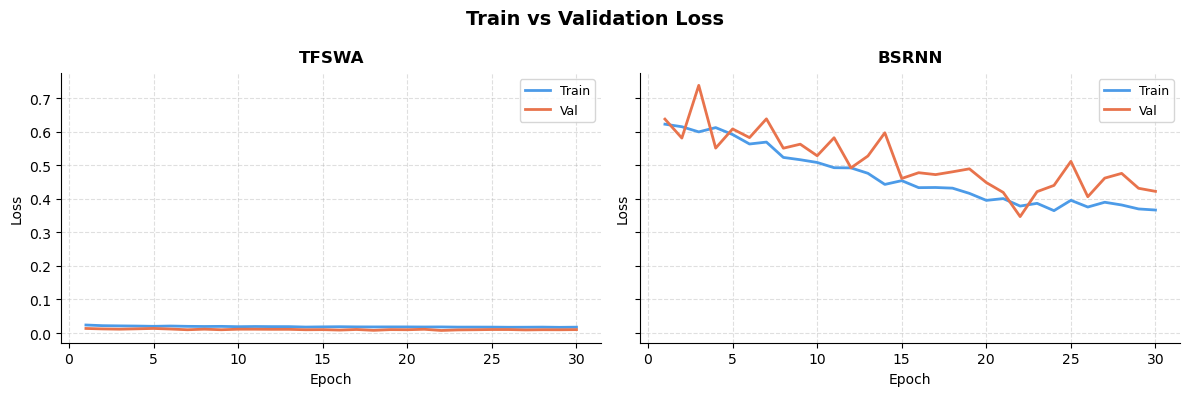

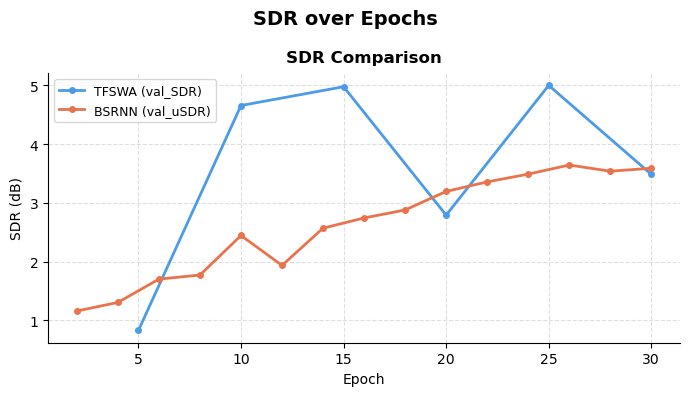

In [12]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# ── Load ──────────────────────────────────────────────────────────────────────
with open("BSRNN/vocals/history.json", "r") as f:
    rnn_data = json.load(f)
with open("TFSWA/vocals/history.json", "r") as f:
    tf_data = json.load(f)

tf_df  = pd.DataFrame(tf_data)
rnn_df = pd.DataFrame(rnn_data)

# ── Consolidate ───────────────────────────────────────────────────────────────
tf_clean = pd.DataFrame({
    "epoch"     : tf_df["epoch"],
    "train_loss": tf_df["train"],
    "val_loss"  : tf_df["val_loss"],
    "val_SDR"   : tf_df["val_SDR"],
}).dropna(subset=["val_loss"])

rnn_clean = pd.DataFrame({
    "epoch"     : rnn_df["epoch"],
    "train_loss": rnn_df["train"],
    "val_loss"  : rnn_df["val"],
    "val_SDR"   : rnn_df["val_uSDR"],
}).dropna(subset=["val_loss"])

COLORS = {"train": "#4C9BE8", "val": "#E8734C"}

def styled_ax(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

# ── Figure 1: Train vs Val Loss per model ─────────────────────────────────────
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
fig1.suptitle("Train vs Validation Loss", fontsize=14, fontweight="bold")

# TFSWA
ax1.plot(tf_clean["epoch"], tf_clean["train_loss"], color=COLORS["train"], label="Train", linewidth=2)
ax1.plot(tf_clean["epoch"], tf_clean["val_loss"],   color=COLORS["val"],   label="Val",   linewidth=2)
styled_ax(ax1, "TFSWA", "Epoch", "Loss")

# BSRNN
ax2.plot(rnn_clean["epoch"], rnn_clean["train_loss"], color=COLORS["train"], label="Train", linewidth=2)
ax2.plot(rnn_clean["epoch"], rnn_clean["val_loss"],   color=COLORS["val"],   label="Val",   linewidth=2)
styled_ax(ax2, "BSRNN", "Epoch", "Loss")

fig1.tight_layout()
fig1.savefig("loss_comparison.png", dpi=150, bbox_inches="tight")

# ── Figure 2: SDR comparison across epochs ────────────────────────────────────
tf_sdr  = tf_clean.dropna(subset=["val_SDR"])
rnn_sdr = rnn_clean.dropna(subset=["val_SDR"])

fig2, ax3 = plt.subplots(figsize=(7, 4))
ax3.plot(tf_sdr["epoch"],  tf_sdr["val_SDR"],  color="#4C9BE8", label="TFSWA (val_SDR)",   linewidth=2, marker="o", markersize=4)
ax3.plot(rnn_sdr["epoch"], rnn_sdr["val_SDR"], color="#E8734C", label="BSRNN (val_uSDR)",  linewidth=2, marker="o", markersize=4)
styled_ax(ax3, "SDR Comparison", "Epoch", "SDR (dB)")

fig2.suptitle("SDR over Epochs", fontsize=14, fontweight="bold")
fig2.tight_layout()
fig2.savefig("sdr_comparison.png", dpi=150, bbox_inches="tight")

plt.show()

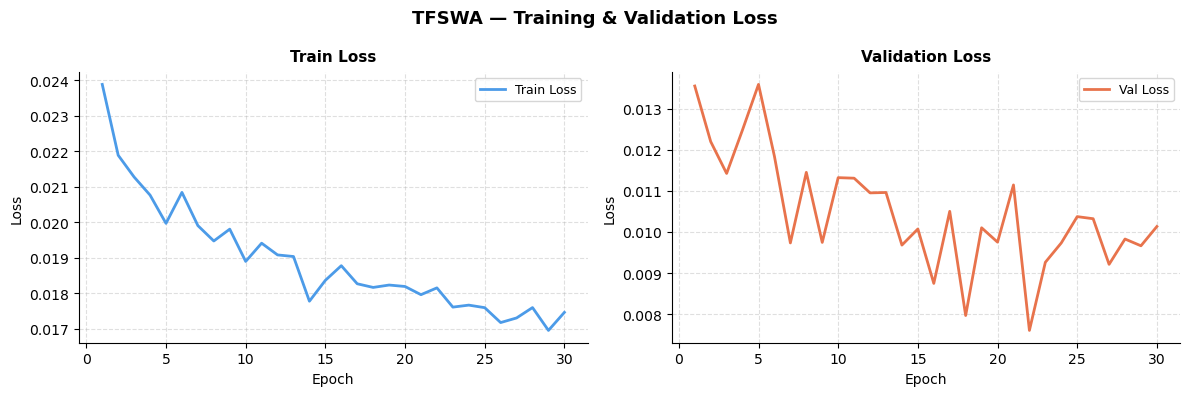

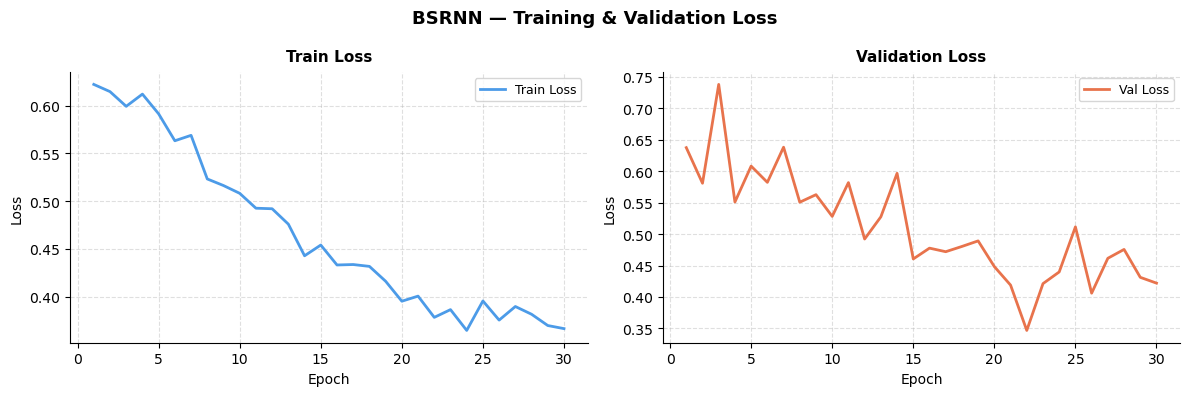

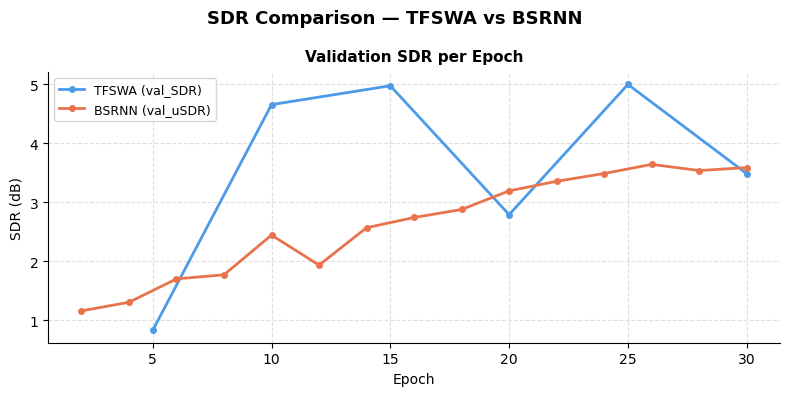

In [13]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# ── Load ──────────────────────────────────────────────────────────────────────
with open("BSRNN/vocals/history.json", "r") as f:
    rnn_data = json.load(f)
with open("TFSWA/vocals/history.json", "r") as f:
    tf_data = json.load(f)

tf_df  = pd.DataFrame(tf_data)
rnn_df = pd.DataFrame(rnn_data)

# ── Consolidate ───────────────────────────────────────────────────────────────
tf_clean = pd.DataFrame({
    "epoch"     : tf_df["epoch"],
    "train_loss": tf_df["train"],
    "val_loss"  : tf_df["val_loss"],
    "val_SDR"   : tf_df["val_SDR"],
}).dropna(subset=["val_loss"])

rnn_clean = pd.DataFrame({
    "epoch"     : rnn_df["epoch"],
    "train_loss": rnn_df["train"],
    "val_loss"  : rnn_df["val"],
    "val_SDR"   : rnn_df["val_uSDR"],
}).dropna(subset=["val_loss"])

# ── Shared style ──────────────────────────────────────────────────────────────
TRAIN_COLOR = "#4C9BE8"
VAL_COLOR   = "#E8734C"

def style_ax(ax, title, ylabel):
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Epoch", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

# ══════════════════════════════════════════════════════════════════════════════
# Figure 1 — TFSWA: Train vs Val Loss
# ══════════════════════════════════════════════════════════════════════════════
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig1.suptitle("TFSWA — Training & Validation Loss", fontsize=13, fontweight="bold")

ax1.plot(tf_clean["epoch"], tf_clean["train_loss"], color=TRAIN_COLOR, linewidth=2, label="Train Loss")
style_ax(ax1, "Train Loss", "Loss")

ax2.plot(tf_clean["epoch"], tf_clean["val_loss"], color=VAL_COLOR, linewidth=2, label="Val Loss")
style_ax(ax2, "Validation Loss", "Loss")

fig1.tight_layout()
fig1.savefig("tfswa_loss.png", dpi=150, bbox_inches="tight")

# ══════════════════════════════════════════════════════════════════════════════
# Figure 2 — BSRNN: Train vs Val Loss
# ══════════════════════════════════════════════════════════════════════════════
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 4))
fig2.suptitle("BSRNN — Training & Validation Loss", fontsize=13, fontweight="bold")

ax3.plot(rnn_clean["epoch"], rnn_clean["train_loss"], color=TRAIN_COLOR, linewidth=2, label="Train Loss")
style_ax(ax3, "Train Loss", "Loss")

ax4.plot(rnn_clean["epoch"], rnn_clean["val_loss"], color=VAL_COLOR, linewidth=2, label="Val Loss")
style_ax(ax4, "Validation Loss", "Loss")

fig2.tight_layout()
fig2.savefig("bsrnn_loss.png", dpi=150, bbox_inches="tight")

# ══════════════════════════════════════════════════════════════════════════════
# Figure 3 — SDR Comparison (epochs where SDR is available)
# ══════════════════════════════════════════════════════════════════════════════
tf_sdr  = tf_clean.dropna(subset=["val_SDR"])
rnn_sdr = rnn_clean.dropna(subset=["val_SDR"])

fig3, ax5 = plt.subplots(figsize=(8, 4))
fig3.suptitle("SDR Comparison — TFSWA vs BSRNN", fontsize=13, fontweight="bold")

ax5.plot(tf_sdr["epoch"],  tf_sdr["val_SDR"],  color="#4C9BE8", linewidth=2, marker="o", markersize=4, label="TFSWA (val_SDR)")
ax5.plot(rnn_sdr["epoch"], rnn_sdr["val_SDR"], color="#E8734C", linewidth=2, marker="o", markersize=4, label="BSRNN (val_uSDR)")
style_ax(ax5, "Validation SDR per Epoch", "SDR (dB)")

fig3.tight_layout()
fig3.savefig("sdr_comparison.png", dpi=150, bbox_inches="tight")

plt.show()

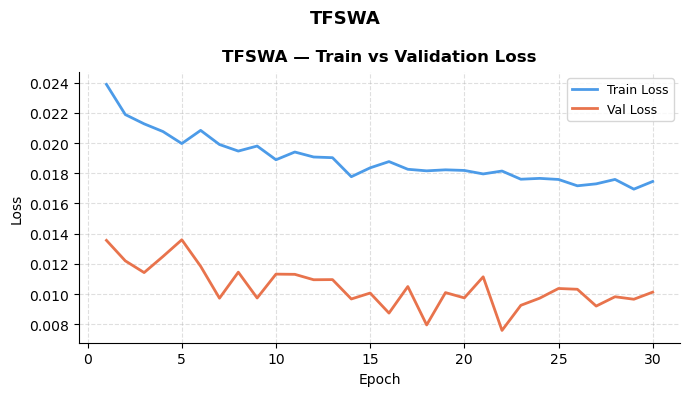

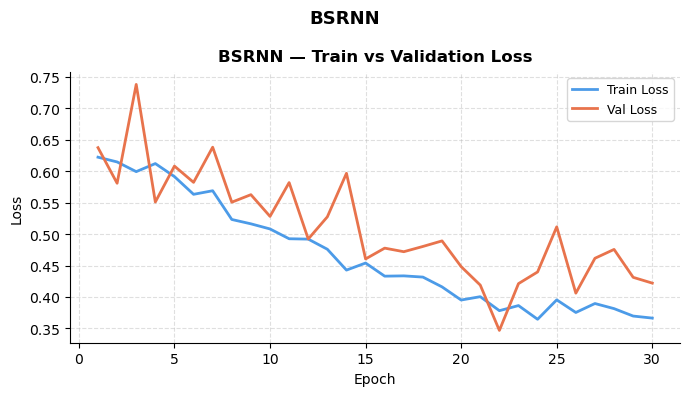

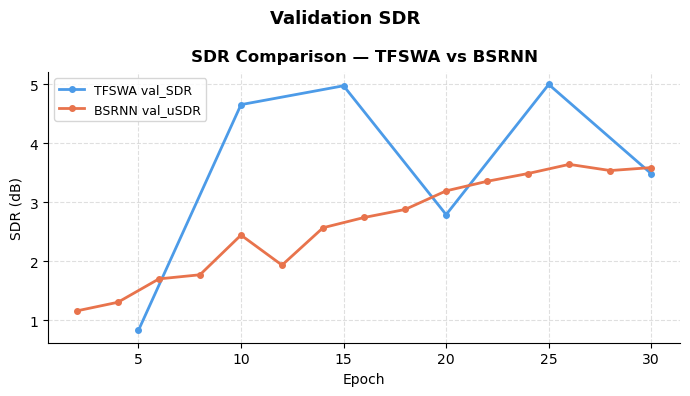

In [14]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# ── Load ──────────────────────────────────────────────────────────────────────
with open("BSRNN/vocals/history.json", "r") as f:
    rnn_data = json.load(f)
with open("TFSWA/vocals/history.json", "r") as f:
    tf_data = json.load(f)

tf_df  = pd.DataFrame(tf_data)
rnn_df = pd.DataFrame(rnn_data)

# ── Consolidate ───────────────────────────────────────────────────────────────
tf_clean = pd.DataFrame({
    "epoch"     : tf_df["epoch"],
    "train_loss": tf_df["train"],
    "val_loss"  : tf_df["val_loss"],
    "val_SDR"   : tf_df["val_SDR"],
}).dropna(subset=["val_loss"])

rnn_clean = pd.DataFrame({
    "epoch"     : rnn_df["epoch"],
    "train_loss": rnn_df["train"],
    "val_loss"  : rnn_df["val"],
    "val_SDR"   : rnn_df["val_uSDR"],
}).dropna(subset=["val_loss"])

# ── Shared style ──────────────────────────────────────────────────────────────
TRAIN_COLOR = "#4C9BE8"
VAL_COLOR   = "#E8734C"

def style_ax(ax, title, ylabel):
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel("Epoch", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

# ── Figure 1: TFSWA — train vs val loss ──────────────────────────────────────
fig1, ax = plt.subplots(figsize=(7, 4))
ax.plot(tf_clean["epoch"], tf_clean["train_loss"], color=TRAIN_COLOR, linewidth=2, label="Train Loss")
ax.plot(tf_clean["epoch"], tf_clean["val_loss"],   color=VAL_COLOR,   linewidth=2, label="Val Loss")
style_ax(ax, "TFSWA — Train vs Validation Loss", "Loss")
fig1.suptitle("TFSWA", fontsize=13, fontweight="bold")
fig1.tight_layout()
fig1.savefig("fig1_tfswa_loss.png", dpi=150, bbox_inches="tight")

# ── Figure 2: BSRNN — train vs val loss ──────────────────────────────────────
fig2, ax = plt.subplots(figsize=(7, 4))
ax.plot(rnn_clean["epoch"], rnn_clean["train_loss"], color=TRAIN_COLOR, linewidth=2, label="Train Loss")
ax.plot(rnn_clean["epoch"], rnn_clean["val_loss"],   color=VAL_COLOR,   linewidth=2, label="Val Loss")
style_ax(ax, "BSRNN — Train vs Validation Loss", "Loss")
fig2.suptitle("BSRNN", fontsize=13, fontweight="bold")
fig2.tight_layout()
fig2.savefig("fig2_bsrnn_loss.png", dpi=150, bbox_inches="tight")

# ── Figure 3: SDR comparison ──────────────────────────────────────────────────
tf_sdr  = tf_clean.dropna(subset=["val_SDR"])
rnn_sdr = rnn_clean.dropna(subset=["val_SDR"])

fig3, ax = plt.subplots(figsize=(7, 4))
ax.plot(tf_sdr["epoch"],  tf_sdr["val_SDR"],  color="#4C9BE8", linewidth=2, marker="o", markersize=4, label="TFSWA val_SDR")
ax.plot(rnn_sdr["epoch"], rnn_sdr["val_SDR"], color="#E8734C", linewidth=2, marker="o", markersize=4, label="BSRNN val_uSDR")
style_ax(ax, "SDR Comparison — TFSWA vs BSRNN", "SDR (dB)")
fig3.suptitle("Validation SDR", fontsize=13, fontweight="bold")
fig3.tight_layout()
fig3.savefig("fig3_sdr_comparison.png", dpi=150, bbox_inches="tight")

plt.show()


--- Summary TFSWA-ResUNet---
  
 - mean_SDR: 4.2440 dB
 - n_songs: 16
 - mean_SAR: 3.2972 dB


 --- Summary TFSWA-ResUNet---
- mean uSDR    = 4.482 dB
- median cSDR  = 3.578 dB
- songs scored = 16
